# Car Price Predictive Analysis

# Notebook 2: Exploratory Data Analysis and Statistics

## Purpose

This notebook explores the cleaned car price dataset to understand the distribution of vehicle prices and investigate relationships between car characteristics and price.

The analysis will use descriptive statistics, visualisations, correlation analysis, and hypothesis testing to identify patterns relevant to the business problem.

## Objectives

- Load and inspect the cleaned dataset produced in Notebook 1.
- Calculate descriptive statistics, including mean, median, variance, and standard deviation.
- Explore the distributions of vehicle prices and important numerical features.
- Investigate relationships between price and vehicle characteristics.
- Compare prices across relevant vehicle categories.
- Formulate and test a justified statistical hypothesis.
- Interpret findings in the context of the business problem.
- Prepare evidence to support the machine-learning analysis in Notebook 3.

## Business Questions

1. How are vehicle prices distributed, and are there signs of skewness?
2. Which vehicle characteristics appear to be associated with price?
3. Do vehicle prices differ between selected, meaningful groups?
4. What conclusions can the statistical analysis support about vehicle pricing?

## Methodology

The analysis will begin with descriptive statistics and data visualisation. Relationships between variables will then be explored using appropriate numerical and graphical methods.

A statistical hypothesis will be selected after inspecting the data. The choice of statistical test will consider the variables being compared and the relevant test assumptions.

## Expected Output

This notebook will produce descriptive statistics, visualisations, statistical test results, and evidence-based interpretations to inform the subsequent machine-learning analysis.

## Import Libraries

The libraries below provide the tools required for data manipulation, numerical calculations, visualisation, and statistical analysis.

- **Pandas:** Load and manipulate the cleaned dataset.
- **NumPy:** Perform numerical calculations.
- **Matplotlib and Seaborn:** Create charts to explore distributions and relationships between variables.
- **Plotly Express:** Create interactive visualisations.
- **SciPy:** Perform statistical tests and support hypothesis testing.

These libraries will be used throughout this notebook to explore vehicle prices, investigate relationships between car characteristics, and evaluate statistical hypotheses.

In [17]:
# Data manipulation and numerical calculations
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistical analysis and hypothesis testing
from scipy import stats
import matplotlib.ticker as ticker

In [18]:
import os
project_dir = r"D:\car-price-predictive-analysis"

os.chdir(project_dir)
print(os.getcwd()) 

D:\car-price-predictive-analysis


## Load the Cleaned Dataset

The cleaned car price dataset exported from Notebook 1 is loaded into a pandas DataFrame for exploratory data analysis and statistical investigation.

The dataset is stored in `outputs/car_prices_cleaned.csv` within the project directory.

The `head()` method displays the first five rows to confirm that the dataset has loaded successfully and to provide an initial view of its structure and values.

In [19]:
# Load the cleaned car price dataset
df = pd.read_csv('outputs/car_prices_cleaned.csv')

# Display the first five rows
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,brand,car_model,price_per_hp,power_to_weight,avg_mpg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,alfa-romeo,giulia,121.576577,0.043564,24.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,alfa-romeo,stelvio,148.648649,0.043564,24.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,alfa-romeo,quadrifoglio,107.142857,0.054552,22.5
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,audi,100ls,136.764706,0.043646,27.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,audi,100ls,151.739130,0.040722,20.0


### Descriptive Statistical Analysis

Descriptive statistics summarise the main characteristics of the dataset and help us understand typical values, variability, and the range of vehicle prices and specifications.

This analysis examines the mean, median, standard deviation, minimum, maximum, and quartiles of selected numerical variables. These measures help us understand the dataset before conducting hypothesis testing and building machine learning models.

The results will help identify important patterns in car prices and vehicle characteristics that deserve further investigation.

In [20]:
# Select all numerical features, excluding car_ID and symboling
numerical_columns = df.select_dtypes(include="number").columns.drop(
    ["car_ID", "symboling"]
)

# Calculate descriptive statistics for the selected features
descriptive_stats = df[numerical_columns].describe().T

# Add variance and median
descriptive_stats["variance"] = df[numerical_columns].var()
descriptive_stats["median"] = df[numerical_columns].median()

# Display the results rounded to two decimal places
display(descriptive_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,variance,median
wheelbase,205.0,98.76,6.02,86.60,94.50,97.00,102.40,120.90,36.26,97.00
carlength,205.0,174.05,12.34,141.10,166.30,173.20,183.10,208.10,152.21,173.20
carwidth,205.0,65.91,2.15,60.30,64.10,65.50,66.90,72.30,4.60,65.50
carheight,205.0,53.72,2.44,47.80,52.00,54.10,55.50,59.80,5.97,54.10
curbweight,205.0,2555.57,520.68,1488.00,2145.00,2414.00,2935.00,4066.00,271107.87,2414.00
enginesize,205.0,126.91,41.64,61.00,97.00,120.00,141.00,326.00,1734.11,120.00
boreratio,205.0,3.33,0.27,2.54,3.15,3.31,3.58,3.94,0.07,3.31
stroke,205.0,3.26,0.31,2.07,3.11,3.29,3.41,4.17,0.10,3.29
compressionratio,205.0,10.14,3.97,7.00,8.60,9.00,9.40,23.00,15.78,9.00
horsepower,205.0,104.12,39.54,48.00,70.00,95.00,116.00,288.00,1563.74,95.00


---

> **Key Findings — Descriptive Statistical Analysis**
>
> - The dataset contains **205 vehicles**, and all numerical features shown have 205 observations.
> - The mean car price is **13,276.71**, while the median is **10,295.00**. The difference suggests a right-skewed price distribution, consistent with the price distribution explored earlier.
> - Engine size has a mean of **126.91** and a median of **120.00**, while horsepower has a mean of **104.12** and a median of **95.00**.
> - Mean curb weight is **2,555.57**, compared with a median of **2,414.00**, indicating variation in vehicle weight.
> - Mean fuel economy is **25.22 mpg in city driving** and **30.75 mpg on highways**. The derived `avg_mpg` feature has a mean of **27.99 mpg**.
> - The range of prices, engine sizes, and horsepower values indicates substantial differences between vehicles in this dataset.
>
> **Conclusion:** Descriptive statistics establish a baseline understanding of vehicle prices and specifications. Further exploratory analysis and hypothesis testing are needed to investigate which characteristics are associated with price differences.

### Detailed Analysis of the Target Variable: Price

The target variable, `price`, represents the vehicle price that the predictive model will aim to estimate.

Measures of central tendency describe a typical price, while measures of dispersion describe how widely prices vary. The mean and standard deviation can be influenced by unusually expensive vehicles, whereas the median and interquartile range (IQR) are more robust to extreme values.

Skewness describes the asymmetry of the price distribution, while kurtosis helps characterise its tails and concentration. These measures support our understanding of the data and inform the choice and interpretation of subsequent statistical methods.

The distribution will be assessed using numerical statistics and the existing histogram and boxplot.

In [21]:
# Calculate detailed descriptive statistics for car prices
price = df["price"]

price_stats = pd.Series({
    "Count": price.count(),
    "Mean": price.mean(),
    "Median": price.median(),
    "Mode": price.mode().tolist(),
    "Standard deviation": price.std(),
    "Variance": price.var(),
    "Minimum": price.min(),
    "First quartile (Q1)": price.quantile(0.25),
    "Third quartile (Q3)": price.quantile(0.75),
    "Maximum": price.max(),
    "Interquartile range (IQR)": (
        price.quantile(0.75) - price.quantile(0.25)
    ),
    "Skewness": price.skew(),
    "Kurtosis (excess)": price.kurt()
})

display(price_stats.to_frame(name="Value").round(2))

,Value
Count,205
Mean,13276.710571
Median,10295.0
Mode,"[5572.0, 6229.0, 6692.0, 7295.0, 7609.0, 7775...."
Standard deviation,7988.852332
Variance,63821761.578398
Minimum,5118.0
First quartile (Q1),7788.0
Third quartile (Q3),16503.0
Maximum,45400.0


---

> **Key Findings — Target Variable Analysis**
>
> - The dataset contains **205 vehicles**.
> - The mean price is **13,276.71**, compared with a median of **10,295**. The higher mean is consistent with a right-skewed distribution.
> - The interquartile range (IQR) is **8,715**, with the middle 50% of prices between **7,788 and 16,503**.
> - The standard deviation is approximately **7,988.85**, indicating substantial variability in vehicle prices.
> - Skewness is **1.78**, indicating a positively skewed distribution.
> - Excess kurtosis is **3.05**, indicating heavier tails and/or a more concentrated centre than a normal distribution.
>
> **Conclusion:** The price distribution is not symmetric and shows substantial variability. The median and IQR provide useful robust summaries alongside the mean and standard deviation. Statistical test selection should also consider the research question, sample sizes, independence and relevant test assumptions.

### Descriptive Statistics for Continuous Features

This section examines four continuous vehicle characteristics: `enginesize`, `horsepower`, `curbweight`, and `avg_mpg`.

For each feature, we will calculate measures of central tendency and spread, together with skewness and the interquartile range (IQR). These statistics help us understand the distribution and variability of each feature.

Potential outliers will be screened using the IQR rule. Values identified by this method will be investigated rather than automatically removed, because they may represent genuine differences between vehicles.

In [22]:
# Select the four continuous vehicle features
continuous_features = [
    "enginesize",
    "horsepower",
    "curbweight",
    "avg_mpg"
]

# Calculate descriptive statistics
continuous_stats = df[continuous_features].describe().T

# Add median, interquartile range (IQR), and skewness
continuous_stats["median"] = df[continuous_features].median()

continuous_stats["IQR"] = (
    continuous_stats["75%"] - continuous_stats["25%"]
)

continuous_stats["skewness"] = df[continuous_features].skew()

# Arrange columns in a logical order
continuous_stats = continuous_stats[
    [
        "count", "mean", "std", "median", "IQR",
        "min", "25%", "50%", "75%", "max", "skewness"
    ]
]

# Display the summary table rounded to two decimal places
display(continuous_stats.round(2))

,count,mean,std,median,IQR,min,25%,50%,75%,max,skewness
enginesize,205.0,126.91,41.64,120.0,44.0,61.0,97.0,120.0,141.0,326.0,1.95
horsepower,205.0,104.12,39.54,95.0,46.0,48.0,70.0,95.0,116.0,288.0,1.41
curbweight,205.0,2555.57,520.68,2414.0,790.0,1488.0,2145.0,2414.0,2935.0,4066.0,0.68
avg_mpg,205.0,27.99,6.67,27.0,9.5,15.0,22.5,27.0,32.0,51.5,0.62


In [23]:
# Enable inline display of Matplotlib plots
%matplotlib inline

print("Matplotlib inline display is enabled.")

Matplotlib inline display is enabled.


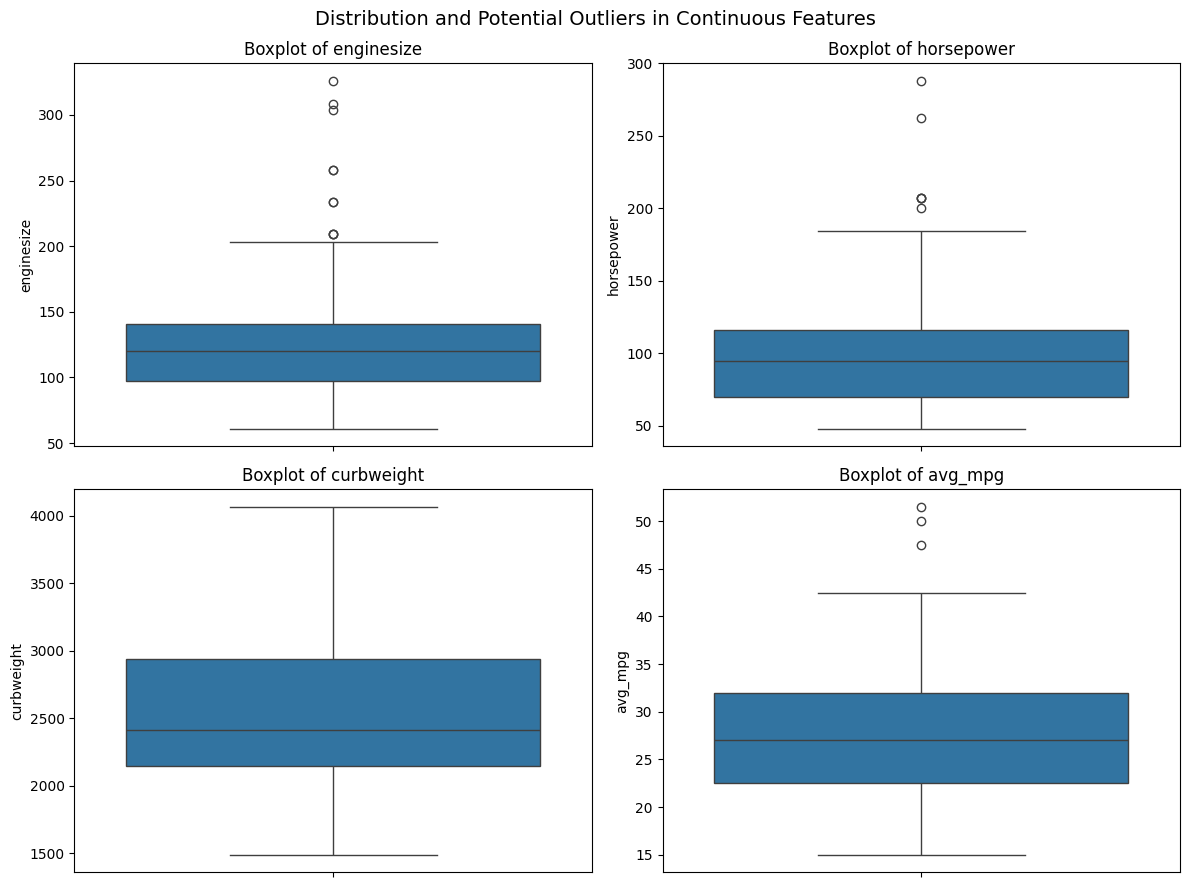

In [24]:
# Create four boxplots in a 2 × 2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Define the features and their positions
plot_features = [
    ("enginesize", axes[0, 0]),
    ("horsepower", axes[0, 1]),
    ("curbweight", axes[1, 0]),
    ("avg_mpg", axes[1, 1])
]

# Draw each boxplot with the correct title and axis label
for feature, ax in plot_features:
    sns.boxplot(data=df, y=feature, ax=ax)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

fig.suptitle(
    "Distribution and Potential Outliers in Continuous Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Outlier Identification Using the IQR Method

The interquartile range (IQR) method identifies potential outliers by examining values outside the expected range of the middle 50% of observations.

The IQR is calculated as the third quartile (Q3) minus the first quartile (Q1).

- **Lower bound:** Q1 − 1.5 × IQR
- **Upper bound:** Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are flagged as potential outliers. These thresholds identify unusual observations but do not prove that the values are errors.

In this project, the method will be applied to engine size, horsepower and average miles per gallon (`avg_mpg`). Potential outliers will be retained unless further investigation identifies a data-quality problem.

In [25]:
# Create a separate copy for outlier analysis
outlier_df = df.copy()

# Calculate average MPG in the copy only
outlier_df["avg_mpg"] = (
    outlier_df["citympg"] + outlier_df["highwaympg"]
) / 2

# Select features for the IQR outlier audit
outlier_features = ["enginesize", "horsepower", "avg_mpg"]

# Store the results
outlier_results = []

for feature in outlier_features:
    # Calculate the first and third quartiles
    q1 = outlier_df[feature].quantile(0.25)
    q3 = outlier_df[feature].quantile(0.75)

    # Calculate the interquartile range
    iqr = q3 - q1

    # Calculate the outlier thresholds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Identify observations outside the thresholds
    outlier_mask = (
        (outlier_df[feature] < lower_bound) |
        (outlier_df[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    # Record the results
    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": (
            outlier_count / len(outlier_df) * 100
        )
    })

# Display the summary table
iqr_outlier_summary = pd.DataFrame(outlier_results)
display(iqr_outlier_summary.round(2))

# Confirm that the original DataFrame was not changed
print("Original df contains avg_mpg:", "avg_mpg" in df.columns)
print("Analysis copy contains avg_mpg:", "avg_mpg" in outlier_df.columns)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,enginesize,97.0,141.0,44.0,31.00,207.00,10,4.88
1,horsepower,70.0,116.0,46.0,1.00,185.00,6,2.93
2,avg_mpg,22.5,32.0,9.5,8.25,46.25,3,1.46


Original df contains avg_mpg: True
Analysis copy contains avg_mpg: True


---

> **Key Findings — IQR Outlier Analysis**
>
> - **Engine size:** 10 observations (4.88%) fall outside the IQR bounds of 31 to 207.
> - **Horsepower:** 6 observations (2.93%) fall outside the bounds of 1 to 185.
> - **Average MPG:** 3 observations (1.46%) fall outside the bounds of 8.25 to 46.25.
> - **Interpretation:** These observations are potential outliers, not necessarily data errors.
> - **Handling decision:** The observations will be retained unless further investigation identifies data-quality problems.
>
> **Conclusion:** The IQR method identified a small proportion of potential outliers. These observations will be retained for subsequent analysis unless evidence indicates that they are incorrect.

## Categorical Feature Analysis

This section examines the frequency and percentage distribution of vehicle manufacturers, fuel types, body styles, and drivetrain configurations.

Understanding the distribution of these categories helps identify common and less-represented vehicle groups before investigating their relationships with car prices and preparing categorical variables for machine learning.

In [26]:
# Select the categorical features for analysis
categorical_features = [
    "brand",
    "fueltype",
    "carbody",
    "drivewheel"
]

# Calculate frequency counts and percentages
for feature in categorical_features:

    print(f"\nFrequency Distribution: {feature}")

    # Count observations in each category
    counts = df[feature].value_counts(dropna=False)

    # Calculate percentages
    percentages = df[feature].value_counts(
        dropna=False,
        normalize=True
    ) * 100

    # Combine counts and percentages into one table
    frequency_table = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })

    display(frequency_table)


Frequency Distribution: brand


,Count,Percentage (%)
brand,,
toyota,32,15.61
nissan,18,8.78
mazda,17,8.29
mitsubishi,13,6.34
honda,13,6.34
volkswagen,12,5.85
subaru,12,5.85
peugeot,11,5.37
volvo,11,5.37



Frequency Distribution: fueltype


,Count,Percentage (%)
fueltype,,
gas,185,90.24
diesel,20,9.76



Frequency Distribution: carbody


,Count,Percentage (%)
carbody,,
sedan,96,46.83
hatchback,70,34.15
wagon,25,12.20
hardtop,8,3.90
convertible,6,2.93



Frequency Distribution: drivewheel


,Count,Percentage (%)
drivewheel,,
fwd,120,58.54
rwd,76,37.07
4wd,9,4.39


---

> **Key Findings — Categorical Feature Analysis**
>
> - **Fuel type:** Gas vehicles account for 90.24% of the dataset, while diesel vehicles account for 9.76%.
> - **Body style:** Sedans are the most common body type (46.83%), followed by hatchbacks (34.15%). Convertibles are the least common, with 6 vehicles (2.93%).
> - **Drivetrain:** Front-wheel-drive vehicles represent 58.54% of the dataset, while rear-wheel-drive vehicles represent 37.07%. Four-wheel-drive vehicles account for only 4.39%.
> - **Manufacturer:** Toyota is the most represented brand, with 32 vehicles (15.61%). Some manufacturers have very few observations.
>
> **Conclusion:** The dataset contains an uneven distribution of vehicle categories. This should be considered when interpreting group comparisons and evaluating model performance.

### Visualising Categorical Feature Distributions

Bar charts are used to visualise the frequency of different vehicle categories. They make it easier to compare the representation of fuel types and body styles in the dataset.

The charts below complement the frequency tables by presenting the number of vehicles in each category visually.

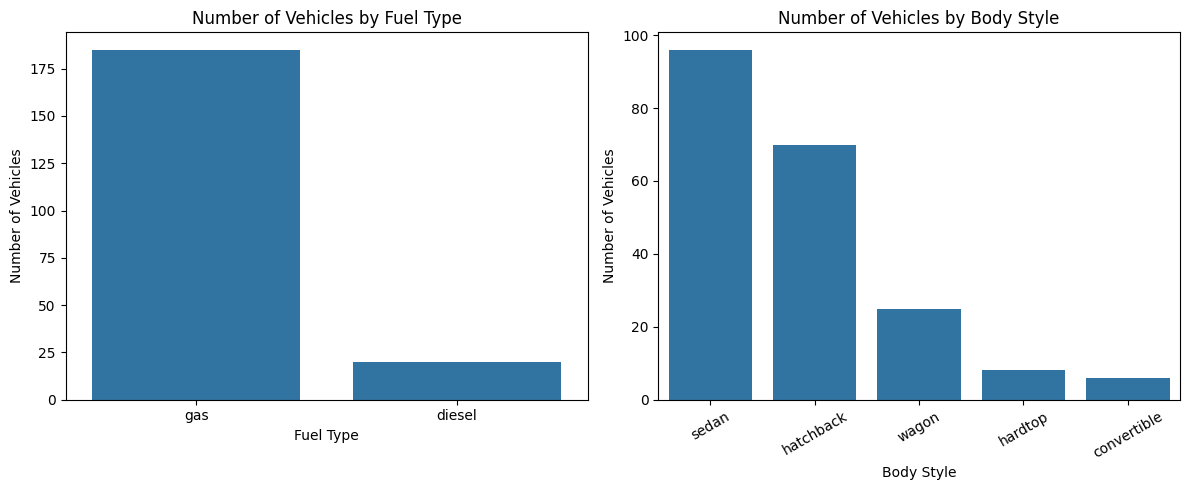

In [27]:
# Create count plots for fuel type and body style
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="fueltype", ax=axes[0])
axes[0].set_title("Number of Vehicles by Fuel Type")
axes[0].set_xlabel("Fuel Type")
axes[0].set_ylabel("Number of Vehicles")

sns.countplot(
    data=df,
    x="carbody",
    order=df["carbody"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Number of Vehicles by Body Style")
axes[1].set_xlabel("Body Style")
axes[1].set_ylabel("Number of Vehicles")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---

> **Key Findings — Categorical Feature Visualisation**
>
> - **Fuel type:** Gas vehicles dominate the dataset, with 185 vehicles compared with only 20 diesel vehicles.
> - **Body style:** Sedans are the most common category (96 vehicles), followed by hatchbacks (70) and wagons (25).
> - **Less-represented categories:** Hardtops and convertibles have relatively few observations, with 8 and 6 vehicles respectively.
> - **Data imbalance:** The unequal representation of categories should be considered when comparing prices across groups and evaluating model performance.
>
> **Conclusion:** The charts show that the dataset is concentrated in gas-powered vehicles and sedan or hatchback body styles. These distributions provide useful context for the subsequent analysis of vehicle prices.

### Car Price by Drivetrain

This analysis examines how car prices vary across drivetrain categories: front-wheel drive (`fwd`), rear-wheel drive (`rwd`), and four-wheel drive (`4wd`).

Grouped descriptive statistics will be used to compare the number of vehicles, mean price, median price, and price variability within each category. A boxplot will then help visualise differences in price distributions and identify potential outliers.

The results will provide context for the subsequent hypothesis test comparing front-wheel-drive and rear-wheel-drive vehicles.

In [28]:
# Summarise car prices by drivetrain category
drivewheel_price_summary = (
    df.groupby("drivewheel")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Display the grouped statistics
display(drivewheel_price_summary)

,count,mean,median,std,min,max
drivewheel,,,,,,
4wd,9,11087.46,9233.0,3988.64,7603.0,17859.17
fwd,120,9239.31,8222.0,3317.93,5118.0,23875.00
rwd,76,19910.81,16912.5,9120.14,6785.0,45400.00


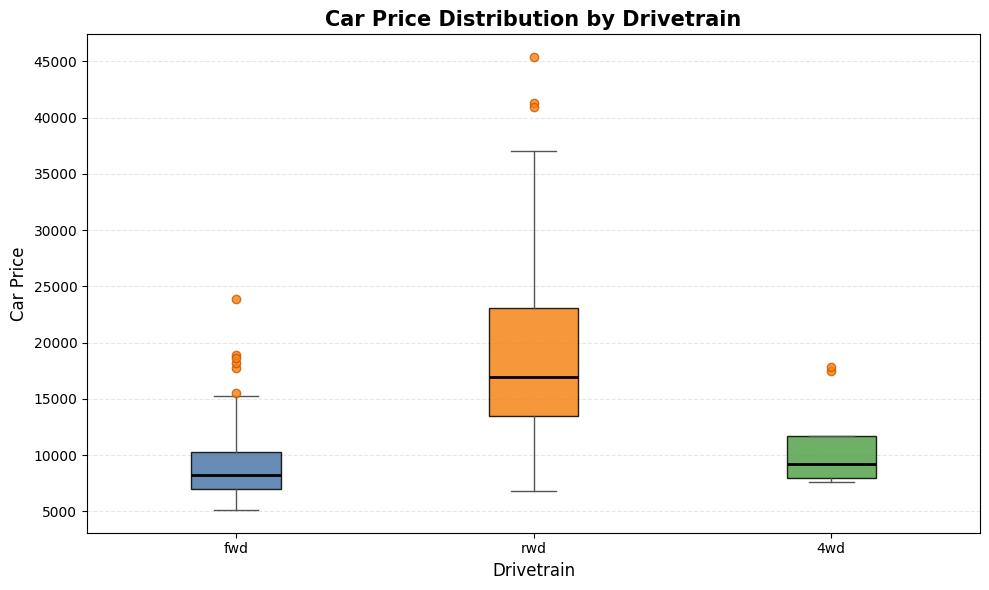

In [29]:
# Compare car prices across drivetrain categories
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare prices for each drivetrain
drivewheel_categories = ["fwd", "rwd", "4wd"]

price_data = [
    df.loc[df["drivewheel"] == category, "price"].dropna()
    for category in drivewheel_categories
]

# Create the boxplot
boxplot = ax.boxplot(
    price_data,
    labels=drivewheel_categories,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#FF7F0E",
        "markeredgecolor": "#C45A00",
        "alpha": 0.8
    }
)

# Apply a different colour to each drivetrain
colors = ["#4C78A8", "#F58518", "#54A24B"]

for patch, color in zip(boxplot["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Add titles and labels
ax.set_title(
    "Car Price Distribution by Drivetrain",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Drivetrain", fontsize=12)
ax.set_ylabel("Car Price", fontsize=12)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---

> **Key Findings — Car Price by Drivetrain**
>
> - **Front-wheel drive (FWD):** The boxplot shows a relatively low median price and a narrower price distribution than RWD vehicles.
> - **Rear-wheel drive (RWD):** The median price is higher, and the distribution is wider, indicating greater variability in this group.
> - **Four-wheel drive (4WD):** The group contains only nine vehicles, so its observed price distribution should be interpreted cautiously.
> - **Potential outliers:** All three groups contain unusually high prices. These observations may represent genuine vehicles and should not be removed automatically.
>
> **Conclusion:** Car prices appear to vary across drivetrain categories in this dataset. A formal hypothesis test will be used to investigate whether the mean prices of FWD and RWD vehicles differ statistically.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to investigate the cleaned dataset, understand the distribution of car prices, identify relationships between vehicle characteristics and price, and explore patterns that may inform business decisions.

This section uses descriptive statistics and visualisations to address the project objective of understanding the factors associated with car prices. The findings will help guide subsequent statistical analysis, hypothesis testing, and machine learning model development.

### Distribution of Car Prices

Understanding the distribution of car prices helps identify typical price ranges, variability, and potential skewness in the dataset. This analysis uses a histogram to show the frequency of prices across different ranges and a box plot to summarise the distribution and highlight potential outliers.

These visualisations will help assess whether car prices are concentrated within a particular range or whether a small number of vehicles have substantially higher prices.

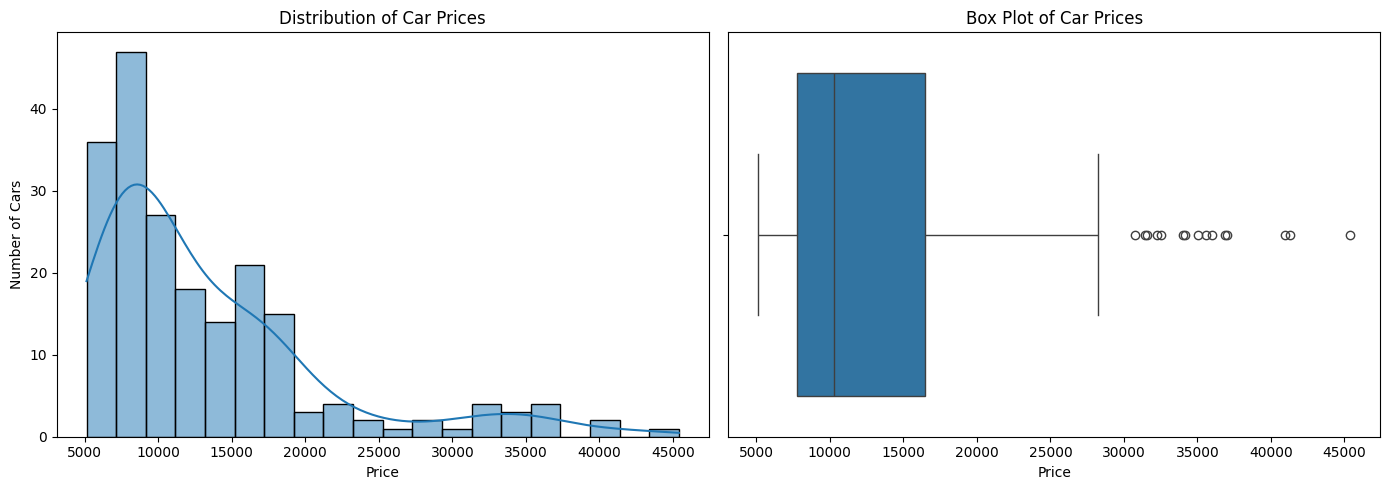

In [30]:
# Create a figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: show the distribution of car prices
sns.histplot(data=df, x="price", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Car Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Cars")

# Box plot: summarise price spread and potential outliers
sns.boxplot(data=df, x="price", ax=axes[1])
axes[1].set_title("Box Plot of Car Prices")
axes[1].set_xlabel("Price")

# Improve layout and display the plots
plt.tight_layout()
plt.show()

---

> **Key Findings — Distribution of Car Prices**
>
> - The histogram shows a **right-skewed distribution**: most cars are concentrated at lower price levels, while fewer cars have much higher prices.
> - The highest concentration of observations appears to be around the lower price ranges, particularly approximately 7,000–10,000.
> - The box plot shows a wide spread of prices and several potential high-price outliers above the upper whisker.
> - A small number of vehicles have prices above 30,000, with the maximum price appearing to be approximately 45,000.
>
> **Business implication:** The company should investigate which vehicle characteristics are associated with higher prices, as these may help explain differences in market positioning.
>
> **Note:** Potential outliers are not necessarily errors. They should be investigated alongside vehicle characteristics before any decision is made to remove or transform them.

### Average Car Price by Manufacturer

Comparing average car prices across manufacturers helps identify differences in price positioning within the dataset. A horizontal bar chart displays the average price for each manufacturer, making it easier to compare brands and identify those with higher or lower average prices.

This analysis supports the business objective of understanding pricing differences between manufacturers. However, average prices may also reflect differences in vehicle characteristics, such as engine size, horsepower, and vehicle weight. Therefore, the results will be interpreted as descriptive comparisons rather than evidence of causation.

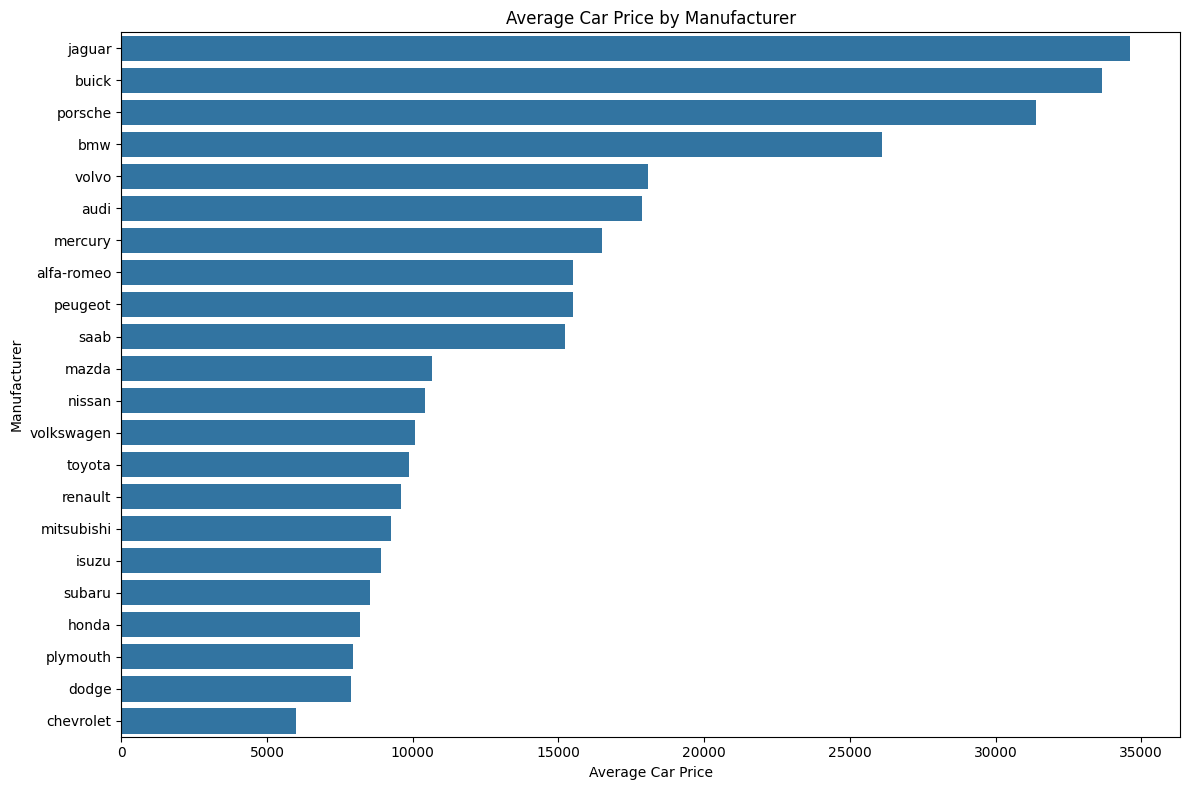

In [31]:
# Calculate the average price for each manufacturer
avg_price_by_brand = (
    df.groupby("brand", as_index=False)["price"]
    .mean()
    .sort_values("price", ascending=False)
)

# Create a bar chart using Seaborn and Matplotlib
plt.figure(figsize=(12, 8))

sns.barplot(
    data=avg_price_by_brand,
    x="price",
    y="brand"
)

# Add titles and labels
plt.title("Average Car Price by Manufacturer")
plt.xlabel("Average Car Price")
plt.ylabel("Manufacturer")

# Format the chart
plt.tight_layout()
plt.show()

---

> **Key Findings — Average Car Price by Manufacturer**
>
> - **Highest average prices:** Jaguar has the highest average price at approximately 34,500, followed by Buick at around 33,700 and Porsche at around 31,400.
> - **Other high-priced manufacturers:** BMW has an average price of approximately 26,100, while Volvo and Audi are both around 18,000.
> - **Lowest average prices:** Chevrolet has the lowest average price at approximately 6,000, followed by Dodge and Plymouth at around 7,800.
> - **Differences between manufacturers:** The substantial variation in average prices suggests that the dataset contains vehicles positioned across different price segments.
>
> **Business implication:** These comparisons can help identify potential competitor groups and price segments. Further analysis of engine size, horsepower, vehicle weight and other characteristics is needed to understand these differences.
>
> **Limitation:** These are descriptive averages for the vehicles in this dataset. They do not establish that manufacturer identity causes a particular price.

## Comparing the Most Expensive Car Models

Identifying the highest-priced car models helps the business understand the premium segment of the market and explore potential pricing opportunities.

A horizontal bar chart is used to rank the 15 most expensive vehicles in the dataset. The colour gradient and price labels make comparisons easier, while the horizontal layout improves the readability of model names.

This analysis focuses on vehicles represented in the dataset and does not necessarily reflect the entire US car market.

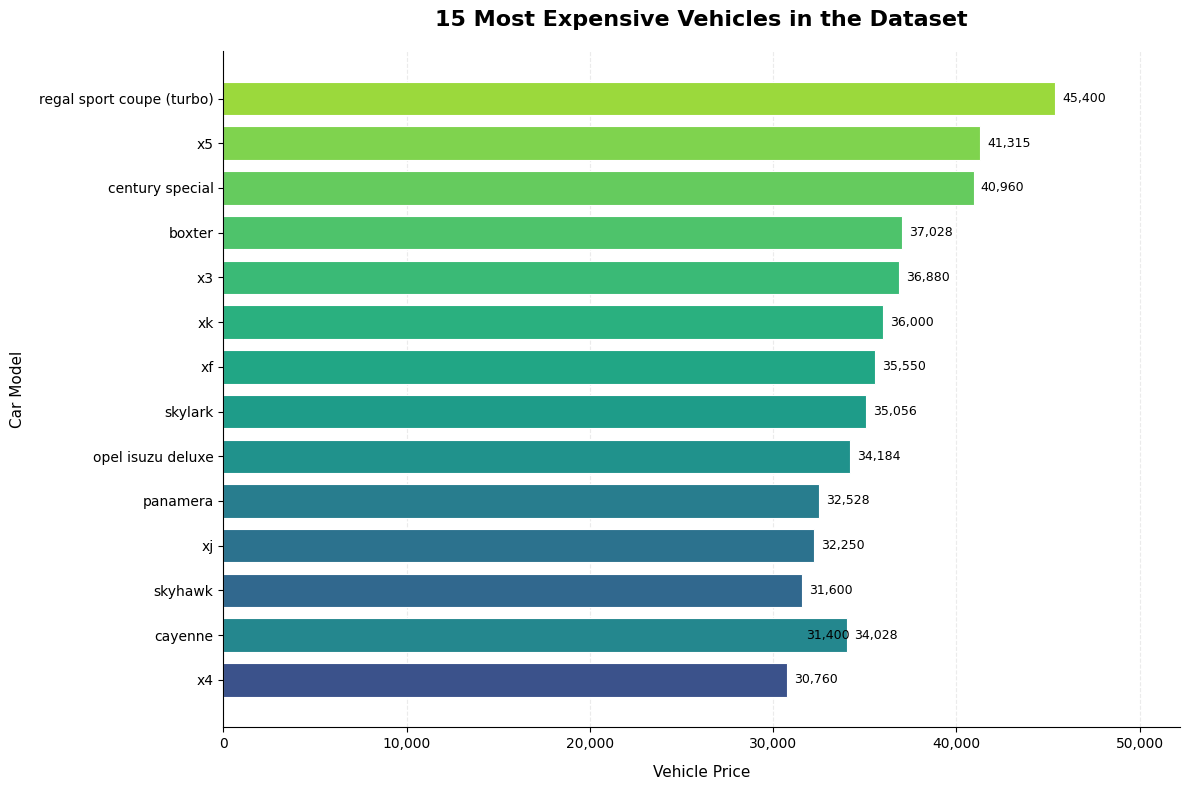

In [32]:
# Select the 15 highest-priced vehicles
top_cars = df.nlargest(15, "price").sort_values(
    "price", ascending=True
)

# Create the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Create a colour gradient from teal to blue
colors = plt.cm.viridis(
    np.linspace(0.25, 0.85, len(top_cars))
)

# Draw horizontal bars
bars = ax.barh(
    top_cars["car_model"],
    top_cars["price"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    height=0.75
)

# Add price labels at the end of each bar
ax.bar_label(
    bars,
    labels=[f"{price:,.0f}" for price in top_cars["price"]],
    padding=5,
    fontsize=9
)

# Add title and axis labels
ax.set_title(
    "15 Most Expensive Vehicles in the Dataset",
    fontsize=16,
    fontweight="bold",
    pad=18
)
ax.set_xlabel("Vehicle Price", fontsize=11, labelpad=10)
ax.set_ylabel("Car Model", fontsize=11, labelpad=10)

# Format the price axis
ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

# Add subtle gridlines
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Improve spacing
ax.set_xlim(0, top_cars["price"].max() * 1.15)
plt.tight_layout()

# Display the chart
plt.show()

> **Key Findings — Highest-Priced Car Models**
>
> - **Highest-priced vehicle:** The Regal Sport Coupe (Turbo) has the highest recorded price in the displayed selection, at approximately 45,400.
>
> - **Premium-priced vehicles:** The BMW X5 and Buick Century Special also appear among the highest-priced vehicles, with recorded prices above 40,000.
>
> - **Price differences:** The selected vehicles span a substantial price range, illustrating the variation between lower-priced entries in this group and the most expensive vehicles.
>
> **Business implication:** The highest-priced vehicles provide examples of the premium segment that the business could investigate when considering product positioning and pricing.
>
> **Limitation:** This chart shows the 15 highest-priced individual vehicles in this dataset, not necessarily the 15 models with the highest average prices. The results should not be generalised to the entire US car market.

### Correlation Analysis of Numerical Variables

Correlation analysis measures the strength and direction of linear relationships between numerical variables. A correlation heatmap presents these relationships visually, making it easier to identify variables associated with car price and potential relationships between predictor features.

This analysis will help identify candidate features for the car price prediction model and highlight possible multicollinearity between predictors. Correlation does not establish causation, and a weak linear correlation does not necessarily mean that two variables have no relationship.

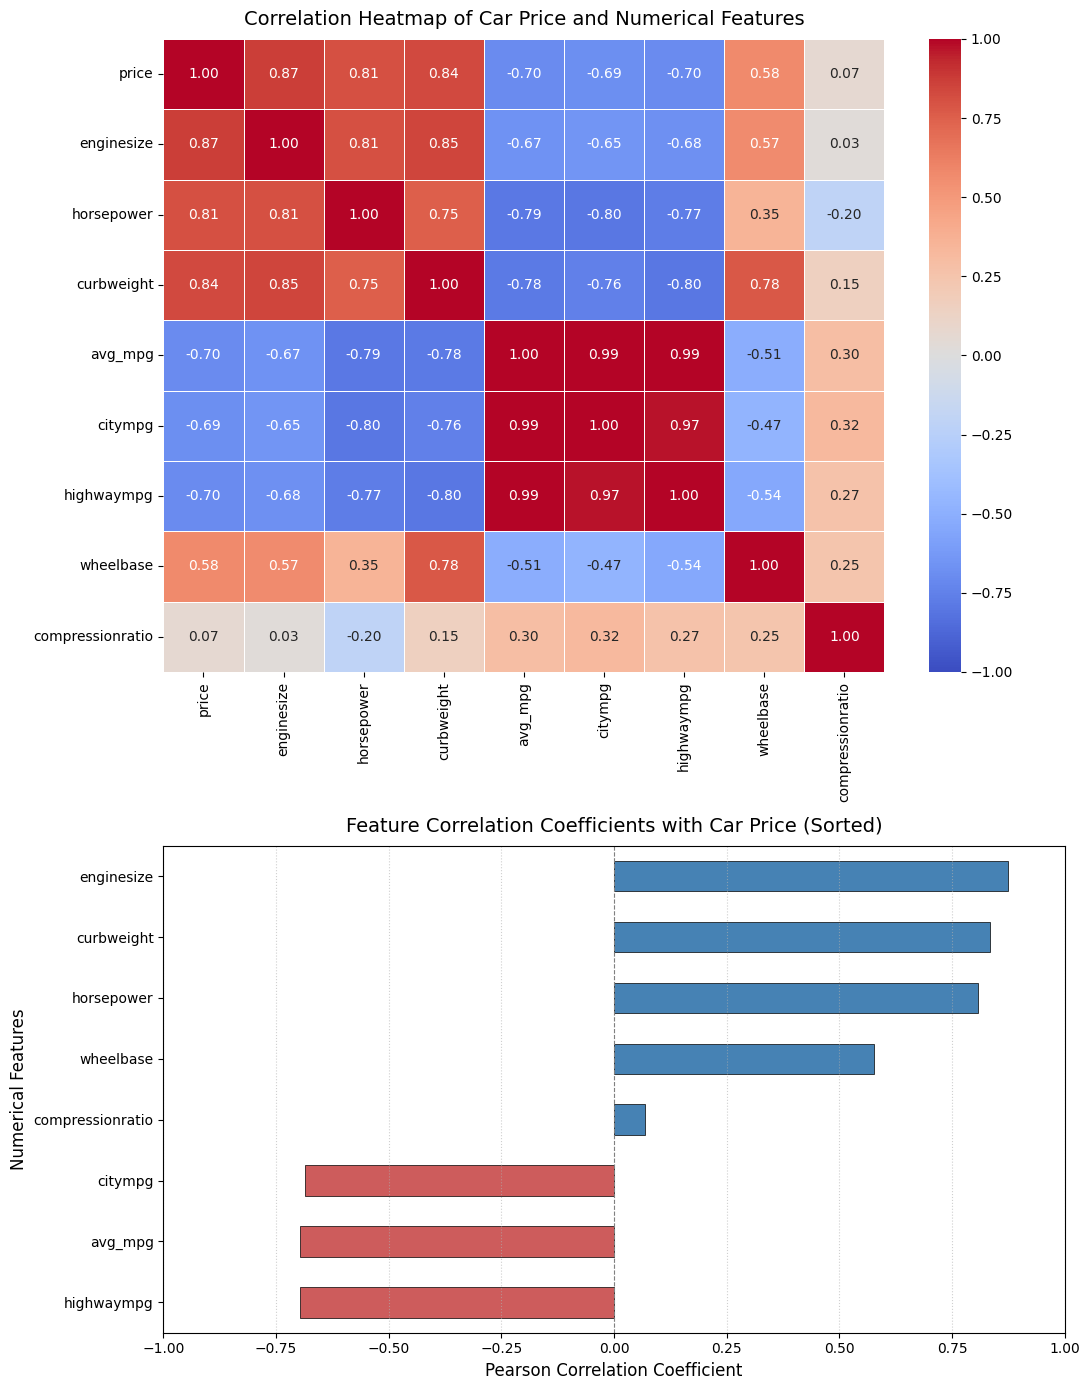

In [33]:
# Select numerical variables relevant to car price analysis
correlation_columns = [
    "price",
    "enginesize",
    "horsepower",
    "curbweight",
    "avg_mpg",
    "citympg",
    "highwaympg",
    "wheelbase",
    "compressionratio"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Extract correlations with 'price', drop 'price' itself, and sort them
price_corr = correlation_matrix["price"].drop("price").sort_values(ascending=True)

# Create a figure with two stacked subplots (Heatmap on top, Bar Chart below)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(11, 14), gridspec_kw={'height_ratios': [1.3, 1]})

# --- 1. Correlation Heatmap ---
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    ax=ax1
)
ax1.set_title("Correlation Heatmap of Car Price and Numerical Features", fontsize=14, pad=10)

# --- 2. Correlation Bar Chart ---
# Use diverging colors: steelblue for positive correlations, indianred for negative
colors = ['indianred' if val < 0 else 'steelblue' for val in price_corr.values]

price_corr.plot(
    kind='barh', 
    ax=ax2, 
    color=colors, 
    edgecolor='black', 
    linewidth=0.5
)

ax2.set_title("Feature Correlation Coefficients with Car Price (Sorted)", fontsize=14, pad=10)
ax2.set_xlabel("Pearson Correlation Coefficient", fontsize=12)
ax2.set_ylabel("Numerical Features", fontsize=12)
ax2.set_xlim(-1, 1)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---

> **Key Findings — Engine Size, Car Price and Vehicle Characteristics**
>
> - **Engine size and price:** The scatter plot shows a positive association between engine size and price. Vehicles with larger engines generally have higher prices, although prices vary between vehicles with similar engine sizes.
>
> - **Horsepower:** Higher-priced vehicles often have higher horsepower values. Because horsepower is correlated with engine size, both features should be considered when investigating price prediction.
>
> - **Drive-wheel type:** Rear-wheel-drive (`rwd`) vehicles appear among many of the higher-priced cars, while front-wheel-drive (`fwd`) vehicles are more concentrated in the lower-to-middle price ranges. Four-wheel-drive (`4wd`) vehicles are relatively few in this dataset.
>
> - **Fuel economy:** Average MPG has a negative correlation with price in the dataset. This relationship may also reflect differences in engine size, horsepower, and vehicle type.
>
> - **Fuel type:** Most observations are petrol (`gas`) vehicles, with fewer diesel vehicles. The smaller diesel group limits the strength of conclusions from a direct comparison.
>
> **Business implication:** Engine size, horsepower, drive-wheel type, and fuel economy are useful candidates for further investigation in the car price prediction model.
>
> **Limitation:** These observations describe associations, not causation. Correlated features may provide overlapping information, and model evaluation is needed to assess their predictive usefulness.

## Comparing Key Vehicle Characteristics with Price

The correlation analysis identified engine size, curb weight, and horsepower as numerical features with strong positive correlations with vehicle price.

Three interactive scatter plots are used to examine these relationships side by side. This comparison helps reveal overall patterns, variation between vehicles, potential clusters, and unusual observations.

The visual analysis provides further insight into the relationships identified by the correlation analysis. However, correlation and visual patterns alone do not establish causation or determine predictive performance.

In [34]:
# Import Plotly subplot tools
from plotly.subplots import make_subplots

# Create a figure with three side-by-side scatter plots
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Engine Size vs Price",
        "Curb Weight vs Price",
        "Horsepower vs Price"
    ),
    horizontal_spacing=0.10
)

# Plot 1: Engine size vs price
fig.add_trace(
    px.scatter(
        df,
        x="enginesize",
        y="price",
        hover_data=["car_model"]
    ).data[0],
    row=1,
    col=1
)

# Plot 2: Curb weight vs price
fig.add_trace(
    px.scatter(
        df,
        x="curbweight",
        y="price",
        hover_data=["car_model"]
    ).data[0],
    row=1,
    col=2
)

# Plot 3: Horsepower vs price
fig.add_trace(
    px.scatter(
        df,
        x="horsepower",
        y="price",
        hover_data=["car_model"]
    ).data[0],
    row=1,
    col=3
)

# Add titles and improve the layout
fig.update_layout(
    title_text="Key Vehicle Characteristics and Car Price",
    template="plotly_white",
    height=500,
    showlegend=False
)

fig.update_yaxes(title_text="Vehicle Price", row=1, col=1)
fig.update_xaxes(title_text="Engine Size (cc)", row=1, col=1)
fig.update_xaxes(title_text="Curb Weight", row=1, col=2)
fig.update_xaxes(title_text="Horsepower", row=1, col=3)

fig.show()

> **Key Findings — Comparing Key Vehicle Characteristics with Price**
>
> - **Engine size:** Vehicle prices generally increase as engine size increases.
> - **Curb weight:** Heavier vehicles tend to have higher prices.
> - **Horsepower:** Vehicles with higher horsepower generally have higher prices.
> - **Overlapping information:** Engine size, curb weight, and horsepower are positively correlated with one another, suggesting that they may provide overlapping information about vehicle size and performance.
> - **Variation:** Vehicles with similar values for these features can still have different prices, indicating that other factors may also influence pricing.
>
> **Business implication:** These three features are promising candidates for further investigation in car price prediction. Their individual contributions should be evaluated alongside other vehicle characteristics.
>
> **Limitation:** These plots show associations, not causation. The visual patterns alone do not establish statistical significance or predictive performance.

## Engine Size, Price and Drive-Wheel Type

The previous analysis identified a positive relationship between engine size and vehicle price. This plot extends the analysis by distinguishing vehicles according to drive-wheel type.

Colouring the points by drivetrain helps explore whether the relationship between engine size and price varies across vehicle groups. Differences between groups should be interpreted cautiously because other characteristics, such as horsepower, vehicle weight, and brand, may also contribute to price differences.

In [35]:
# Create an interactive scatter plot coloured by drive-wheel type
fig = px.scatter(
    df,
    x="enginesize",
    y="price",
    color="drivewheel",
    hover_data=["car_model", "horsepower", "curbweight"],
    title="Engine Size and Vehicle Price by Drive-Wheel Type",
    labels={
        "enginesize": "Engine Size (cc)",
        "price": "Vehicle Price",
        "drivewheel": "Drive-Wheel Type",
        "car_model": "Car Model",
        "horsepower": "Horsepower",
        "curbweight": "Curb Weight"
    }
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Engine Size (cc)",
    yaxis_title="Vehicle Price",
    legend_title="Drive-Wheel Type"
)

fig.show()

> **Key Findings — Engine Size, Price and Drive-Wheel Type**
>
> - **Rear-wheel drive (rwd):** RWD vehicles appear across a wider range of engine sizes and prices, including many of the highest-priced vehicles in the dataset.
>
> - **Front-wheel drive (fwd):** FWD vehicles are concentrated mainly at lower engine sizes and lower-to-middle price levels.
>
> - **Four-wheel drive (4wd):** Relatively few 4WD observations are visible, so conclusions about this group should be cautious.
>
> - **Engine size and price:** The positive relationship between engine size and price is visible across the plot, but the distribution differs between drive-wheel groups.
>
> **Business implication:** Drive-wheel type may be a useful feature for predicting car prices, alongside engine size, horsepower, and curb weight.
>
> **Limitation:** The plot shows associations, not causation. Differences between groups may also reflect other vehicle characteristics, and the smaller 4WD group limits comparisons.

In [36]:
# Create a violin plot to compare vehicle price distributions by fuel type
fig = px.violin(
    df,
    x="fueltype",
    y="price",
    color="fueltype",
    box=True,
    points=False,
    hover_data=["car_model"],
    title="Vehicle Price Distribution by Fuel Type",
    labels={
        "fueltype": "Fuel Type",
        "price": "Vehicle Price",
        "car_model": "Car Model"
    }
)

# Format the chart
fig.update_layout(
    template="plotly_white",
    xaxis_title="Fuel Type",
    yaxis_title="Vehicle Price",
    showlegend=False
)

# Display the interactive plot
fig.show()

> **Key Findings — Vehicle Price Distribution by Fuel Type**
>
> - **Typical prices:** The diesel group has a higher median vehicle price than the petrol (`gas`) group in this dataset.
>
> - **Price distribution:** Petrol vehicles are concentrated around lower prices, with a long upper tail containing some expensive vehicles. Diesel prices also vary considerably and extend into the higher price ranges.
>
> - **Variation:** Both fuel types show a broad price distribution, indicating that fuel type alone does not explain vehicle price differences.
>
> **Business implication:** Fuel type may be useful when analysing vehicle prices, but it should be considered alongside other characteristics, such as engine size, horsepower, and curb weight.
>
> **Limitation:** The dataset contains substantially fewer diesel vehicles than petrol vehicles. The apparent difference in distributions should not be interpreted as evidence that diesel fuel itself causes higher prices.

## Vehicle Price Across Fuel-Economy Groups

Average fuel economy (`avg_mpg`) has a negative correlation with vehicle price (r ≈ -0.70).

To investigate this relationship using a different visualisation, vehicles are grouped into fuel-economy categories. A bar chart will compare the mean price across these groups.

This approach helps show whether average vehicle prices differ across fuel-economy levels. The results describe an association and do not establish that fuel economy causes price differences.

In [37]:
# Create three fuel-economy groups based on the data distribution
df["mpg_group"] = pd.qcut(
    df["avg_mpg"],
    q=3,
    labels=["Low MPG", "Medium MPG", "High MPG"],
    duplicates="drop"
)

# Calculate mean price and 95% confidence intervals for each group
summary = (
    df.groupby("mpg_group", observed=True)["price"]
    .agg(["mean", "count", "std"])
    .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = summary["se"] * stats.t.ppf(
    0.975, summary["count"] - 1
)

# Create an interactive bar chart
fig = px.bar(
    summary,
    x="mpg_group",
    y="mean",
    error_y="ci95",
    text_auto=".0f",
    title="Mean Vehicle Price by Fuel-Economy Group",
    labels={
        "mpg_group": "Fuel-Economy Group",
        "mean": "Mean Vehicle Price"
    },
    hover_data=["count"]
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Fuel-Economy Group",
    yaxis_title="Mean Vehicle Price"
)

fig.show()

> **Key Findings — Fuel Economy and Mean Vehicle Price**
>
> - **Low fuel economy:** Vehicles in the low-MPG group have the highest mean price, approximately 20,776.
>
> - **Medium fuel economy:** The mean price decreases to approximately 10,597.
>
> - **High fuel economy:** Vehicles in the high-MPG group have the lowest mean price, approximately 7,469.
>
> - **Consistent negative pattern:** Mean vehicle price decreases across the three fuel-economy groups, supporting the negative correlation identified in the earlier analysis.
>
> **Business implication:** Fuel economy may help explain differences in vehicle prices. However, engine size, horsepower, vehicle weight, and vehicle type may also contribute to this pattern.
>
> **Limitation:** These groups are based on the distribution of average MPG, and the chart compares group means rather than individual vehicles. The pattern shows an association, not evidence that fuel economy causes prices to decrease.

---

## EDA Conclusion

The exploratory data analysis examined the distribution of car prices, numerical vehicle characteristics, categorical feature frequencies, potential outliers, and relationships between variables.

The main findings are:

- **Price distribution:** Car prices are right-skewed, with substantial variation between lower-priced and higher-priced vehicles.
- **Important relationships:** Engine size, horsepower, and curb weight show strong positive correlations with price in this dataset.
- **Categorical distributions:** Manufacturers, fuel types, body styles, and drivetrain categories are unevenly represented.
- **Potential outliers:** The IQR method identified observations outside the expected ranges for engine size, horsepower, and average MPG. These observations have been retained pending further investigation.
- **Overlapping features:** Average MPG is strongly correlated with city and highway MPG because it is derived from these variables. This overlap should be considered during feature selection.

**Conclusion:** EDA has identified useful patterns and potential predictors for further analysis. However, correlations alone do not establish causation or statistical significance. The next stages will use statistical testing and predictive modelling to investigate price differences and evaluate how accurately car prices can be estimated.

## Hypothesis Testing

Hypothesis testing uses statistical methods to assess whether an observed difference in a sample provides sufficient evidence of a difference between groups.

This section investigates whether mean car prices differ between front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles in the dataset.

### Research Question

Is there a statistically significant difference in mean car prices between FWD and RWD vehicles?

### Hypotheses

- **Null hypothesis (H₀):** The population mean car prices for FWD and RWD vehicles are equal.
- **Alternative hypothesis (H₁):** The population mean car prices for FWD and RWD vehicles are different.

### Significance Level

The significance level is set at **α = 0.05**.

The analysis will examine group sizes and price distributions before selecting a suitable statistical test. A statistically significant result would indicate evidence of a difference in mean prices, but would not establish that drivetrain type causes the difference.

In [38]:
# Select front-wheel-drive and rear-wheel-drive vehicles
drive_groups = df[
    df["drivewheel"].isin(["fwd", "rwd"])
].copy()

# Calculate descriptive statistics for car prices in each group
drive_price_summary = (
    drive_groups.groupby("drivewheel")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Display the results
display(drive_price_summary)

,count,mean,median,std,min,max
drivewheel,,,,,,
fwd,120,9239.31,8222.0,3317.93,5118.0,23875.0
rwd,76,19910.81,16912.5,9120.14,6785.0,45400.0


### Welch's Independent-Samples t-Test

Welch's independent-samples t-test is used to assess whether the population mean prices of two independent groups differ significantly. Unlike the standard Student's t-test, Welch's test does not assume equal population variances.

In this analysis, we compare the prices of front-wheel-drive (`fwd`) and rear-wheel-drive (`rwd`) vehicles.

- **Null hypothesis (H₀):** The population mean prices of FWD and RWD vehicles are equal.
- **Alternative hypothesis (H₁):** The population mean prices of FWD and RWD vehicles are different.
- **Significance level (α):** 0.05.

The p-value will be compared with the significance level to determine whether the null hypothesis should be rejected. The test assesses evidence of a difference in mean prices; it does not establish causation.

In [39]:
# Import the statistical test
from scipy.stats import ttest_ind

# Extract prices for each drivetrain group
fwd_prices = df.loc[df["drivewheel"] == "fwd", "price"]
rwd_prices = df.loc[df["drivewheel"] == "rwd", "price"]

# Perform Welch's independent-samples t-test
t_statistic, p_value = ttest_ind(
    fwd_prices,
    rwd_prices,
    equal_var=False,
    alternative="two-sided"
)

# Display the results
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Compare the p-value with the significance level
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is evidence of a difference in mean prices.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of a difference in mean prices.")

T-statistic: -9.7983
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: There is evidence of a difference in mean prices.


---

> **Key Findings — Welch's Independent-Samples t-Test**
>
> - **Test statistic:** The calculated t-statistic is -9.7983.
> - **P-value:** The p-value is below 0.05 and is displayed as 0.000000 when rounded to six decimal places.
> - **Decision:** Reject the null hypothesis.
> - **Interpretation:** There is statistically significant evidence that mean car prices differ between front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles in this dataset.
> - **Direction of the difference:** The sample mean price for RWD vehicles (19,910.81) is higher than the sample mean for FWD vehicles (9,239.31).
>
> **Conclusion:** The results provide strong evidence of a difference in mean prices between the two drivetrain groups. This is an association in the observed dataset and does not establish that drivetrain type causes higher prices.

### Confidence Interval and Effect of the Difference

The p-value helps assess statistical significance, while a confidence interval estimates the plausible range for the difference between the population mean prices of RWD and FWD vehicles.

A 95% confidence interval will be calculated for the difference in mean prices (RWD minus FWD). If the interval does not include zero, this is consistent with a statistically significant difference at the 5% level for a two-sided test.

The exact p-value will also be displayed in scientific notation to avoid rounding a very small value to zero.

In [40]:
# Import the required functions
from scipy.stats import ttest_ind
from math import sqrt

# Perform Welch's t-test and retain the full result
test_result = ttest_ind(
    fwd_prices,
    rwd_prices,
    equal_var=False,
    alternative="two-sided"
)

# Calculate the difference in sample means (RWD minus FWD)
mean_difference = rwd_prices.mean() - fwd_prices.mean()

# Calculate the standard error for Welch's test
n_fwd = len(fwd_prices)
n_rwd = len(rwd_prices)

var_fwd = fwd_prices.var(ddof=1)
var_rwd = rwd_prices.var(ddof=1)

standard_error = sqrt(
    var_fwd / n_fwd + var_rwd / n_rwd
)

# Calculate Welch-Satterthwaite degrees of freedom
degrees_freedom = (
    (var_fwd / n_fwd + var_rwd / n_rwd) ** 2
    / (
        (var_fwd / n_fwd) ** 2 / (n_fwd - 1)
        + (var_rwd / n_rwd) ** 2 / (n_rwd - 1)
    )
)

# Calculate the 95% confidence interval
from scipy.stats import t

critical_value = t.ppf(0.975, degrees_freedom)

lower_bound = mean_difference - critical_value * standard_error
upper_bound = mean_difference + critical_value * standard_error

# Display the results
print(f"Mean price difference (RWD - FWD): {mean_difference:.2f}")
print(f"T-statistic: {test_result.statistic:.4f}")
print(f"Exact p-value: {test_result.pvalue:.6e}")
print(f"Degrees of freedom: {degrees_freedom:.2f}")
print(f"95% confidence interval: ({lower_bound:.2f}, {upper_bound:.2f})")

Mean price difference (RWD - FWD): 10671.50
T-statistic: -9.7983
Exact p-value: 9.634370e-16
Degrees of freedom: 87.71
95% confidence interval: (8507.01, 12835.99)


---

> **Key Findings — Welch's t-Test and Confidence Interval**
>
> - **Mean price difference:** RWD vehicles have a sample mean price 10,671.50 price units higher than FWD vehicles.
> - **Test statistic:** Welch's t-statistic is -9.7983, with approximately 87.71 degrees of freedom.
> - **P-value:** The exact p-value is approximately 9.63 × 10⁻¹⁶, which is substantially below the significance level of 0.05.
> - **Decision:** Reject the null hypothesis.
> - **95% confidence interval:** The estimated difference in population mean prices (RWD minus FWD) ranges from 8,507.01 to 12,835.99. The interval excludes zero.
>
> **Conclusion:** The results provide strong statistical evidence of a difference in mean prices between FWD and RWD vehicles. In this dataset, RWD vehicles have higher average prices. However, this observational comparison does not establish that drivetrain type causes higher prices; other characteristics, such as engine size, horsepower, and vehicle brand, may also contribute.

## Pearson Correlation Hypothesis Tests

The Welch t-test examines differences in mean car prices between drivetrain groups. Pearson correlation tests will complement this analysis by examining whether car price has a statistically significant linear relationship with selected numerical vehicle characteristics.

For each selected feature:

- **Null hypothesis (H₀):** The population Pearson correlation between the feature and car price is zero (ρ = 0).
- **Alternative hypothesis (H₁):** The population Pearson correlation is not zero (ρ ≠ 0).

The significance level is set at α = 0.05. Pearson's correlation coefficient (r) measures the direction and strength of the linear relationship, while the p-value assesses the evidence against the null hypothesis.

These tests identify statistical associations, not causal relationships. Their assumptions and the possibility of multiple-testing effects will also be considered.

In [41]:
from scipy.stats import pearsonr
import pandas as pd

# Select numerical features to test against car price
features = ["enginesize", "horsepower", "curbweight", "avg_mpg"]

results = []

# Calculate Pearson correlation and p-value for each feature
for feature in features:
    r, p_value = pearsonr(df[feature], df["price"])

    results.append({
        "Feature": feature,
        "Pearson correlation (r)": r,
        "p-value": p_value,
        "Significant at 0.05": p_value < 0.05
    })

# Display the results in a table
correlation_tests = pd.DataFrame(results)
correlation_tests.round(4)

,Feature,Pearson correlation (r),p-value,Significant at 0.05
0,enginesize,0.8741,0.0,True
1,horsepower,0.8081,0.0,True
2,curbweight,0.8353,0.0,True
3,avg_mpg,-0.6968,0.0,True


In [42]:
# Display p-values in scientific notation
correlation_tests.style.format({
    "Pearson correlation (r)": "{:.4f}",
    "p-value": "{:.3e}"
})

,Feature,Pearson correlation (r),p-value,Significant at 0.05
0,enginesize,0.8741,1.355e-65,True
1,horsepower,0.8081,1.483e-48,True
2,curbweight,0.8353,1.214e-54,True
3,avg_mpg,-0.6968,3.992e-31,True


> **Key findings**
>
> All four features show statistically significant linear correlations with car price at the 5% significance level (p < 0.05).
>
> - **Engine size:** Strong positive correlation (r = 0.8741).
> - **Horsepower:** Strong positive correlation (r = 0.8081).
> - **Curb weight:** Strong positive correlation (r = 0.8353).
> - **Average MPG:** Strong negative correlation (r = -0.6968).
>
> **Conclusion:** Engine size has the strongest observed linear correlation with price among these four features. These relationships do not establish causation.

### Multiple-Testing Correction: Holm Method

Four Pearson correlation tests were conducted to investigate the relationships between car price and selected numerical vehicle characteristics. To account for multiple hypothesis testing, the Holm correction is applied to control the family-wise error rate at a significance level of α = 0.05.

The adjusted p-values will be used to determine whether each correlation remains statistically significant after the correction.

In [43]:
from statsmodels.stats.multitest import multipletests

# Apply Holm correction to the four correlation tests
correlation_tests["Holm-adjusted p-value"] = multipletests(
    correlation_tests["p-value"],
    alpha=0.05,
    method="holm"
)[1]

correlation_tests["Significant after Holm correction"] = (
    correlation_tests["Holm-adjusted p-value"] < 0.05
)

# Display the updated results
correlation_tests.style.format({
    "Pearson correlation (r)": "{:.4f}",
    "p-value": "{:.3e}",
    "Holm-adjusted p-value": "{:.3e}"
})

,Feature,Pearson correlation (r),p-value,Significant at 0.05,Holm-adjusted p-value,Significant after Holm correction
0,enginesize,0.8741,1.355e-65,True,5.419e-65,True
1,horsepower,0.8081,1.483e-48,True,2.967e-48,True
2,curbweight,0.8353,1.214e-54,True,3.643e-54,True
3,avg_mpg,-0.6968,3.992e-31,True,3.992e-31,True


> **Key Findings**
>
> All four vehicle characteristics show statistically significant correlations with car price after the Holm correction (adjusted p < 0.05).
>
> - **Engine size:** Strongest positive correlation (r = 0.8741).
> - **Curb weight:** Strong positive correlation (r = 0.8353).
> - **Horsepower:** Strong positive correlation (r = 0.8081).
> - **Average MPG:** Strong negative correlation (r = -0.6968).
>
> **Conclusion:** Engine size has the strongest observed linear correlation with car price among the four features tested.
>
> **Limitation:** These results show associations, not causation. The vehicle characteristics may be related to one another, so their individual correlations should be interpreted with care.

## Welch's ANOVA: Comparing Prices Across Categories

Welch's Analysis of Variance (ANOVA) is used to investigate whether mean car prices differ across body style, fuel type, and drivetrain categories. It is appropriate when group variances are unequal.

**Null hypothesis (H₀):** The population mean car prices are equal across all groups for the selected categorical feature.

**Alternative hypothesis (H₁):** At least one population group mean differs.

The significance level is set at α = 0.05. P-values are adjusted using the Holm method to account for multiple comparisons.

A statistically significant result suggests that at least one group mean differs, but it does not identify which specific groups differ. These observational results do not establish causation.

### Checking the Equal-Variance Assumption

Levene's test, using the median, checks whether the group variances are equal.

- **Null hypothesis (H₀):** The group variances are equal.
- **Alternative hypothesis (H₁):** At least one group has a different variance.
- **Significance level:** α = 0.05.

If p < 0.05, there is evidence that the equal-variance assumption may be violated. Welch's ANOVA is therefore used to compare mean prices because it does not require equal group variances.

In [44]:
from scipy.stats import levene
import pandas as pd

# Categorical features to check
categorical_features = ["carbody", "fueltype", "drivewheel"]

variance_results = []

for feature in categorical_features:
    # Separate car prices into groups
    groups = [
        group["price"].to_numpy()
        for _, group in df[[feature, "price"]].dropna().groupby(feature)
    ]

    # Test whether group variances are equal
    statistic, p_value = levene(*groups, center="median")

    variance_results.append({
        "Feature": feature,
        "Levene statistic": statistic,
        "p-value": p_value,
        "Variance assumption": (
            "Not rejected" if p_value >= 0.05
            else "Potentially violated"
        )
    })

# Display results
variance_results = pd.DataFrame(variance_results)

variance_results.style.format({
    "Levene statistic": "{:.3f}",
    "p-value": "{:.3e}"
})

,Feature,Levene statistic,p-value,Variance assumption
0,carbody,6.486,6.299e-05,Potentially violated
1,fueltype,0.306,5.810e-01,Not rejected
2,drivewheel,19.603,1.657e-08,Potentially violated


### Welch's ANOVA: Comparing Group Means

Levene's test indicated that the equal-variance assumption may be violated for body style and drivetrain. Therefore, Welch's ANOVA is used to compare mean car prices across the categories of body style, fuel type, and drivetrain.

Welch's ANOVA is more robust than classical one-way ANOVA when group variances are unequal. The significance level is α = 0.05.

- **Null hypothesis (H₀):** All population group means are equal.
- **Alternative hypothesis (H₁):** At least one population group mean differs.

The p-values will be adjusted using the Holm method to account for the three comparisons.

In [45]:
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multitest import multipletests
import pandas as pd

categorical_features = ["carbody", "fueltype", "drivewheel"]
welch_results = []

for feature in categorical_features:
    groups = [
        group["price"].dropna().to_numpy()
        for _, group in df[[feature, "price"]]
        .dropna()
        .groupby(feature)
        if len(group) >= 2
    ]

    result = anova_oneway(
        data=[group for group in groups],
        use_var="unequal"
    )

    welch_results.append({
        "Feature": feature,
        "Welch F-statistic": result.statistic,
        "p-value": result.pvalue
    })

welch_results = pd.DataFrame(welch_results)

welch_results["Holm-adjusted p-value"] = multipletests(
    welch_results["p-value"],
    alpha=0.05,
    method="holm"
)[1]

welch_results["Significant at 0.05"] = (
    welch_results["Holm-adjusted p-value"] < 0.05
)

welch_results.style.format({
    "Welch F-statistic": "{:.3f}",
    "p-value": "{:.3e}",
    "Holm-adjusted p-value": "{:.3e}"
})

,Feature,Welch F-statistic,p-value,Holm-adjusted p-value,Significant at 0.05
0,carbody,5.427,3.560e-03,7.119e-03,True
1,fueltype,2.401,1.346e-01,1.346e-01,False
2,drivewheel,46.818,1.621e-08,4.863e-08,True


> ### Key Findings — Welch's ANOVA with Holm Correction
>
> - **Car body:** The Holm-adjusted p-value is 0.007119, below 0.05. Reject the null hypothesis; there is statistically significant evidence that mean car prices differ across at least some body-style groups.
>
> - **Fuel type:** The Holm-adjusted p-value is 0.1346, above 0.05. Fail to reject the null hypothesis; there is insufficient evidence of a difference in mean car prices between fuel-type groups.
>
> - **Drivewheel:** The Holm-adjusted p-value is 4.863 × 10⁻⁸, below 0.05. Reject the null hypothesis; there is statistically significant evidence that mean car prices differ across at least some drivetrain groups.
>
> **Conclusion:** After applying the Holm correction, statistically significant differences in mean car prices were found across body-style and drivetrain categories, but not across fuel-type categories. Welch's ANOVA does not identify which specific groups differ; post-hoc comparisons would be needed. These findings show associations, not causation.